In [1]:
import os
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    average_precision_score,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

from xgboost import XGBClassifier

import joblib

print("Environment ready.")

Environment ready.


In [2]:
#cell 2

DATA_PATH = "/kaggle/input/datasets/ealaxi/paysim1/PS_20174392719_1491204439457_log.csv"

df = pd.read_csv(DATA_PATH)

print("Dataset shape:", df.shape)
display(df.head())

Dataset shape: (6362620, 11)


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [3]:
#cell 3

DROP_COLUMNS = [
    "newbalanceOrig",
    "newbalanceDest",
    "nameOrig",
    "nameDest",
    "isFlaggedFraud"
]

df = df.drop(columns=DROP_COLUMNS, errors="ignore")
df = df.drop_duplicates()

df = df.dropna(
    subset=[
        "step",
        "type",
        "amount",
        "oldbalanceOrg",
        "oldbalanceDest",
        "isFraud"
    ]
)

df = df.sort_values("step").reset_index(drop=True)

print("Cleaned shape:", df.shape)

Cleaned shape: (6361742, 6)


In [4]:
#cell 4

df["hour"] = df["step"] % 24
df["day"] = df["step"] // 24

df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24)
df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)

df["log_amount"] = np.log1p(df["amount"])

df["amount_to_origin_balance"] = (
    df["amount"] / (df["oldbalanceOrg"] + 1.0)
)

df = pd.get_dummies(
    df,
    columns=["type"],
    prefix="type",
    dtype=int
)

transaction_types = [
    "CASH_IN",
    "CASH_OUT",
    "DEBIT",
    "PAYMENT",
    "TRANSFER"
]

for t in transaction_types:
    col = f"type_{t}"
    if col not in df.columns:
        df[col] = 0

y = df["isFraud"].astype(int)

X = df.drop(columns=["isFraud"])

print("X shape:", X.shape)
print("y shape:", y.shape)

display(X.head())

X shape: (6361742, 15)
y shape: (6361742,)


,step,amount,oldbalanceOrg,oldbalanceDest,hour,day,hour_sin,hour_cos,log_amount,amount_to_origin_balance,type_CASH_IN,type_CASH_OUT,type_DEBIT,type_PAYMENT,type_TRANSFER
0,1,42012.45,350501.24,350501.24,1,0,0.258819,0.965926,10.645745,0.119864,1,0,0,0,0
1,1,5831.05,333749.58,0.00,1,0,0.258819,0.965926,8.671124,0.017471,0,0,0,1,0
2,1,9855.36,327918.53,0.00,1,0,0.258819,0.965926,9.195872,0.030054,0,0,0,1,0
3,1,10726.49,318063.17,0.00,1,0,0.258819,0.965926,9.280565,0.033724,0,0,0,1,0
4,1,1833.22,57589.00,0.00,1,0,0.258819,0.965926,7.514375,0.031832,0,0,0,1,0


In [5]:
#cell 5

print("Fraud distribution:")
display(y.value_counts())

print("\nFraud rate:")
print(f"{y.mean() * 100:.4f}%")

Fraud distribution:


isFraud
0    6353545
1       8197
Name: count, dtype: int64


Fraud rate:
0.1288%


In [6]:
#cell 6

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    stratify=y,
    random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=42
)

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Train: (4453219, 15)
Validation: (954261, 15)
Test: (954262, 15)


In [7]:
#cell 7

scale_pos_weight = y_train.value_counts()[0] / y_train.value_counts()[1]

print("scale_pos_weight:", scale_pos_weight)

scale_pos_weight: 775.0925409550366


In [8]:
#cell 8

model = XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="aucpr",
    scale_pos_weight=scale_pos_weight,
    tree_method="hist",
    random_state=42,
    n_jobs=-1
)

model.fit(
    X_train,
    y_train,
    eval_set=[(X_val, y_val)],
    verbose=50
)

[0]	validation_0-aucpr:0.76676
[50]	validation_0-aucpr:0.96369
[100]	validation_0-aucpr:0.96374
[150]	validation_0-aucpr:0.97001
[200]	validation_0-aucpr:0.97237
[250]	validation_0-aucpr:0.97403
[300]	validation_0-aucpr:0.97479
[350]	validation_0-aucpr:0.97507
[400]	validation_0-aucpr:0.97536
[450]	validation_0-aucpr:0.97529
[499]	validation_0-aucpr:0.97560


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='aucpr', feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=500,
              n_jobs=-1, num_parallel_tree=None, ...)

In [9]:
#cell 9

val_proba = model.predict_proba(X_val)[:, 1]
val_pred = (val_proba >= 0.5).astype(int)

pr_auc = average_precision_score(y_val, val_proba)
roc_auc = roc_auc_score(y_val, val_proba)
precision = precision_score(y_val, val_pred, zero_division=0)
recall = recall_score(y_val, val_pred, zero_division=0)
f1 = f1_score(y_val, val_pred, zero_division=0)

print(f"Validation PR-AUC : {pr_auc:.6f}")
print(f"Validation ROC-AUC: {roc_auc:.6f}")
print(f"Validation Precision: {precision:.6f}")
print(f"Validation Recall   : {recall:.6f}")
print(f"Validation F1       : {f1:.6f}")

Validation PR-AUC : 0.975610
Validation ROC-AUC: 0.999586
Validation Precision: 0.647812
Validation Recall   : 0.987795
Validation F1       : 0.782469


In [10]:
#cell 10

test_proba = model.predict_proba(X_test)[:, 1]
test_pred = (test_proba >= 0.5).astype(int)

print(f"Test PR-AUC : {average_precision_score(y_test, test_proba):.6f}")
print(f"Test ROC-AUC: {roc_auc_score(y_test, test_proba):.6f}")
print(f"Test Precision: {precision_score(y_test, test_pred, zero_division=0):.6f}")
print(f"Test Recall   : {recall_score(y_test, test_pred, zero_division=0):.6f}")
print(f"Test F1       : {f1_score(y_test, test_pred, zero_division=0):.6f}")

Test PR-AUC : 0.973713
Test ROC-AUC: 0.999902
Test Precision: 0.641791
Test Recall   : 0.978862
Test F1       : 0.775274


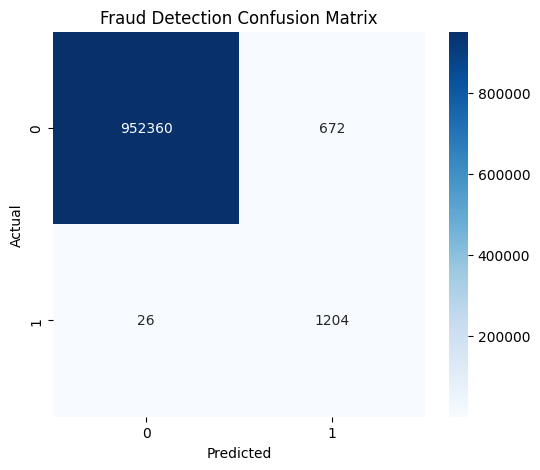

In [11]:
#cell 11

cm = confusion_matrix(y_test, test_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Fraud Detection Confusion Matrix")
plt.show()

,importance
amount_to_origin_balance,0.582300
type_CASH_IN,0.175435
type_PAYMENT,0.091956
amount,0.024839
oldbalanceOrg,0.024625
log_amount,0.024340
type_TRANSFER,0.022675
type_CASH_OUT,0.020015
hour,0.013038
type_DEBIT,0.006656


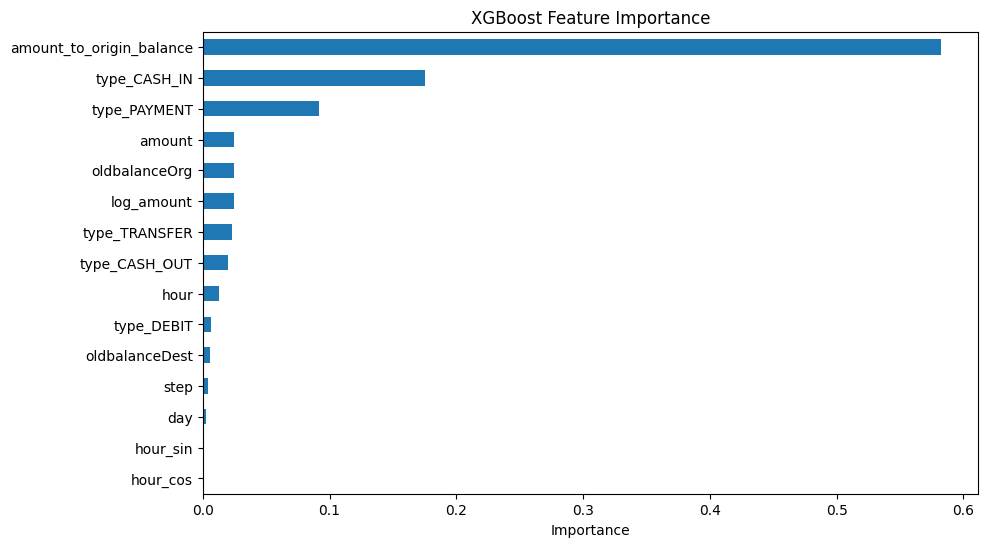

In [12]:
#cell 12

importance = (
    pd.Series(model.feature_importances_, index=X.columns)
    .sort_values(ascending=False)
)

display(importance.to_frame("importance").head(15))

plt.figure(figsize=(10, 6))
importance.head(15).sort_values().plot(kind="barh")

plt.title("XGBoost Feature Importance")
plt.xlabel("Importance")
plt.show()

In [13]:
#cell 13

MODEL_PATH = "/kaggle/working/fraudshield_transaction_xgb.joblib"

joblib.dump(
    {
        "model": model,
        "features": X.columns.tolist()
    },
    MODEL_PATH
)

print("Model saved:", MODEL_PATH)

Model saved: /kaggle/working/fraudshield_transaction_xgb.joblib


In [14]:
#cell 14

import shap

print("SHAP version:", shap.__version__)

SHAP version: 0.51.0


In [15]:
#cell 15

SHAP_SAMPLE_SIZE = 5000

X_shap = X_test.sample(
    n=min(SHAP_SAMPLE_SIZE, len(X_test)),
    random_state=42
)

print("SHAP sample shape:", X_shap.shape)

SHAP sample shape: (5000, 15)


In [16]:
#cell 16

explainer = shap.TreeExplainer(model)

shap_values = explainer.shap_values(X_shap)

print("SHAP values shape:", np.array(shap_values).shape)

SHAP values shape: (5000, 15)


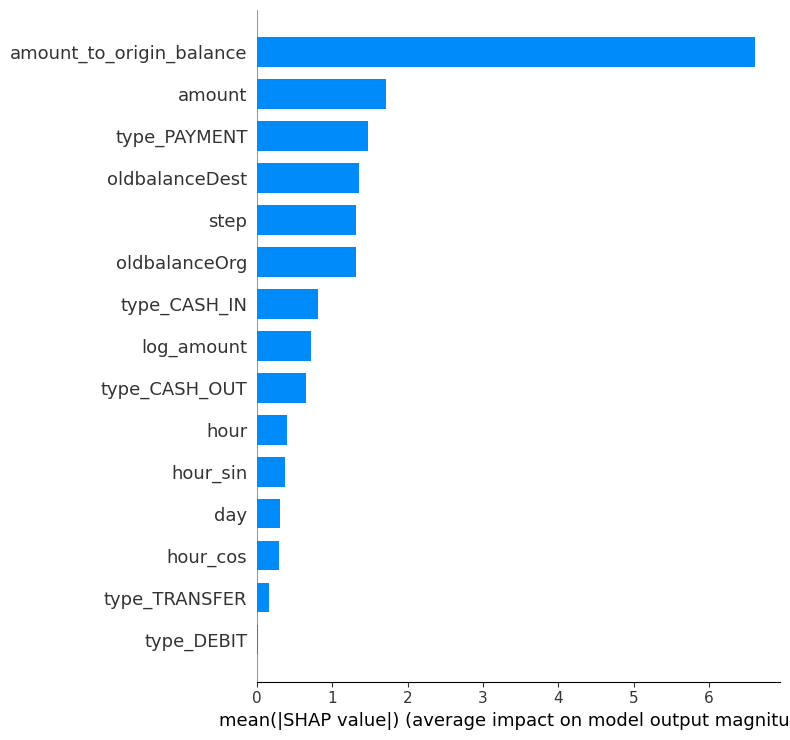

In [17]:
#cell 17

shap.summary_plot(
    shap_values,
    X_shap,
    plot_type="bar",
    max_display=15
)

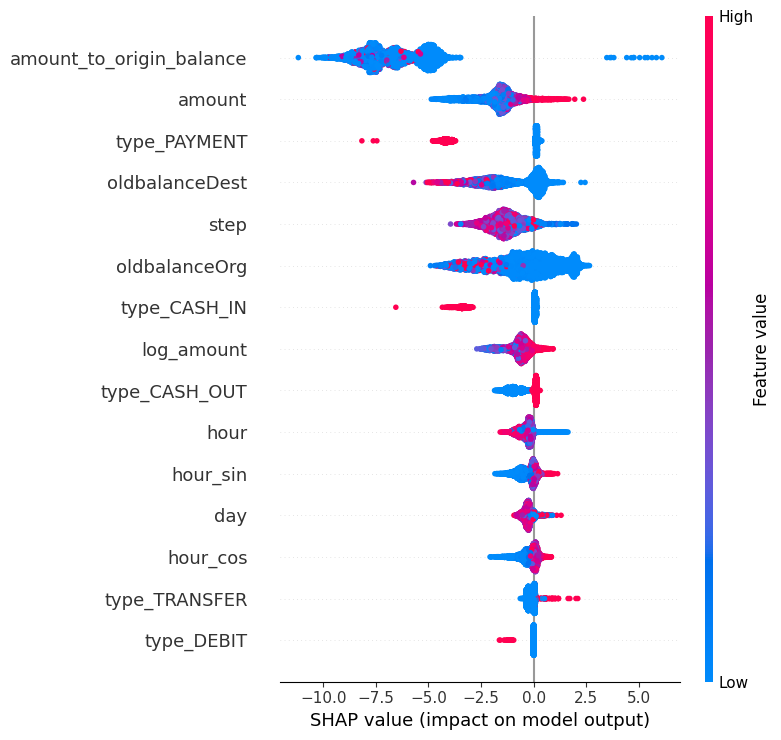

In [18]:
#cell 18

shap.summary_plot(
    shap_values,
    X_shap,
    max_display=15
)

In [19]:
#cell 19

sample_predictions = model.predict_proba(X_shap)[:, 1]

fraud_indices = np.argsort(sample_predictions)[-10:]

display(
    X_shap.iloc[fraud_indices].assign(
        fraud_probability=sample_predictions[fraud_indices]
    ).sort_values(
        "fraud_probability",
        ascending=False
    )
)

,step,amount,oldbalanceOrg,oldbalanceDest,hour,day,hour_sin,hour_cos,log_amount,amount_to_origin_balance,type_CASH_IN,type_CASH_OUT,type_DEBIT,type_PAYMENT,type_TRANSFER,fraud_probability
1030496,77,9039246.82,9039246.82,0.00,5,3,0.965926,2.588190e-01,16.017087,1.000000,0,0,0,0,1,1.000000
6007565,435,1143937.73,1143937.73,0.00,3,18,0.707107,7.071068e-01,13.949988,0.999999,0,0,0,0,1,1.000000
1030616,87,114339.10,114339.10,0.00,15,3,-0.707107,-7.071068e-01,11.646933,0.999991,0,0,0,0,1,0.999992
6356689,710,23134.17,23134.17,0.00,14,29,-0.500000,-8.660254e-01,10.049109,0.999957,0,0,0,0,1,0.999913
1030409,70,167067.78,167067.78,169160.19,22,2,-0.500000,8.660254e-01,12.026161,0.999994,0,1,0,0,0,0.995355
2758915,212,52131.40,53030.00,0.00,20,8,-0.866025,5.000000e-01,10.861542,0.983036,0,1,0,0,0,0.957988
886442,42,92708.98,94992.00,0.00,18,1,-1.000000,-1.836970e-16,11.437231,0.975956,0,1,0,0,0,0.265445
830198,41,272685.23,274458.29,1244163.18,17,1,-0.965926,-2.588190e-01,12.516077,0.993536,0,1,0,0,0,0.241070
789926,40,318266.57,321060.48,475116.20,16,1,-0.866025,-5.000000e-01,12.670648,0.991295,0,1,0,0,0,0.186837
465166,19,150581.86,0.00,0.00,19,0,-0.965926,2.588190e-01,11.922269,150581.860000,0,1,0,0,0,0.181127


In [20]:
#cell 20

SHAP_DIR = "/kaggle/working/fraudshield_shap"
os.makedirs(SHAP_DIR, exist_ok=True)

plt.figure()
shap.summary_plot(
    shap_values,
    X_shap,
    plot_type="bar",
    max_display=15,
    show=False
)

plt.tight_layout()
plt.savefig(
    f"{SHAP_DIR}/shap_feature_importance.png",
    dpi=200,
    bbox_inches="tight"
)

plt.close()

print("SHAP analysis saved to:", SHAP_DIR)

SHAP analysis saved to: /kaggle/working/fraudshield_shap


In [21]:
#cell 21

MODEL_PATH = "/kaggle/working/fraudshield_transaction_xgb_final.joblib"

artifact = {
    "model": model,
    "features": X.columns.tolist(),
    "threshold": 0.5,
    "model_type": "XGBoost",
    "feature_engineering": [
        "hour",
        "day",
        "hour_sin",
        "hour_cos",
        "log_amount",
        "amount_to_origin_balance",
        "one_hot_transaction_type"
    ]
}

joblib.dump(artifact, MODEL_PATH)

print("Final transaction model saved:")
print(MODEL_PATH)

Final transaction model saved:
/kaggle/working/fraudshield_transaction_xgb_final.joblib


In [22]:
# Compare performance without amount_to_origin_balance

DROP_TEST_FEATURE = "amount_to_origin_balance"

X_reduced = X.drop(columns=[DROP_TEST_FEATURE])

X_train_r, X_temp_r, y_train_r, y_temp_r = train_test_split(
    X_reduced,
    y,
    test_size=0.30,
    stratify=y,
    random_state=42
)

X_val_r, X_test_r, y_val_r, y_test_r = train_test_split(
    X_temp_r,
    y_temp_r,
    test_size=0.50,
    stratify=y_temp_r,
    random_state=42
)

scale_pos_weight_r = (
    y_train_r.value_counts()[0] /
    y_train_r.value_counts()[1]
)

model_reduced = XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="aucpr",
    scale_pos_weight=scale_pos_weight_r,
    tree_method="hist",
    random_state=42,
    n_jobs=-1
)

model_reduced.fit(
    X_train_r,
    y_train_r,
    eval_set=[(X_val_r, y_val_r)],
    verbose=50
)

test_proba_r = model_reduced.predict_proba(X_test_r)[:, 1]
test_pred_r = (test_proba_r >= 0.5).astype(int)

print("WITHOUT amount_to_origin_balance")
print("--------------------------------")
print(
    "PR-AUC:",
    average_precision_score(y_test_r, test_proba_r)
)
print(
    "ROC-AUC:",
    roc_auc_score(y_test_r, test_proba_r)
)
print(
    "Precision:",
    precision_score(y_test_r, test_pred_r, zero_division=0)
)
print(
    "Recall:",
    recall_score(y_test_r, test_pred_r, zero_division=0)
)
print(
    "F1:",
    f1_score(y_test_r, test_pred_r, zero_division=0)
)

[0]	validation_0-aucpr:0.19713
[50]	validation_0-aucpr:0.81294
[100]	validation_0-aucpr:0.86241
[150]	validation_0-aucpr:0.88578
[200]	validation_0-aucpr:0.90185
[250]	validation_0-aucpr:0.91425
[300]	validation_0-aucpr:0.91982
[350]	validation_0-aucpr:0.92494
[400]	validation_0-aucpr:0.92925
[450]	validation_0-aucpr:0.93414
[499]	validation_0-aucpr:0.93573
WITHOUT amount_to_origin_balance
--------------------------------
PR-AUC: 0.9272150481378021
ROC-AUC: 0.9994460205296343
Precision: 0.20819643783503372
Recall: 0.9788617886178862
F1: 0.34336232710680165
